In [1]:
import numpy as np

class TinyNet:
    def __init__(self, n_input, n_hidden, n_output):
        self.W1 = np.random.randn(n_hidden,n_input) 
        self.W2 = np.random.randn(n_output,n_hidden) 
        self.b1 = np.zeros((n_hidden,1))
        self.b2 = np.zeros((n_output,1))

    def forward(self, X):
        sigmoid = lambda z: 1.0 / (1.0 + np.exp(-z))

        self.z1 = self.W1 @ X + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = self.W2 @ self.a1 + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2
    
    def backward(self, X, Y):
        """
        X: inputs, shape (n_input, m)
        Y: true targets, shape (n_output, m)
        Computes gradients via backprop. Assumes forward() was already called.
        """
        m = X.shape[1]

        dA2 = (2/m) * (self.a2 - Y)
        delta2 = dA2 * (self.a2 * (1 - self.a2))

        self.dW2 = delta2 @ self.a1.T
        self.db2 = np.sum(delta2, axis=1, keepdims=True)

        delta1 = (self.W2.T @ delta2) * (self.a1 * (1 - self.a1))

        self.dW1 = delta1 @ X.T
        self.db1 = np.sum(delta1, axis=1, keepdims=True)

    def train(self, X, Y, epochs, lr):
        """
        X: inputs (n_input, m),  Y: targets (n_output, m)
        epochs: how many full passes over the data
        lr: learning rate (eta)
        """
        losses = []
        for epoch in range(epochs):
            self.forward(X)
            loss = np.mean((self.a2 - Y) ** 2)
            losses.append(loss)
            self.backward(X, Y)

            self.W1 -= lr * self.dW1
            self.W2 -= lr * self.dW2
            self.b1 -= lr * self.db1
            self.b2 -= lr * self.db2

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} — loss: {loss:.6f}")
        return losses

In [2]:
net = TinyNet(n_input=4, n_hidden=3, n_output=2)
X = np.random.randn(4, 5)
out = net.forward(X)
print("Output shape:", out.shape)

Output shape: (2, 5)


In [3]:
net = TinyNet(4, 3, 2)
X = np.random.randn(4, 5)
Y = np.random.randn(2, 5)

net.forward(X)
net.backward(X, Y)

print("dW1:", net.dW1.shape, "should be", net.W1.shape)
print("dW2:", net.dW2.shape, "should be", net.W2.shape)
print("db1:", net.db1.shape, "should be", net.b1.shape)
print("db2:", net.db2.shape, "should be", net.b2.shape)

dW1: (3, 4) should be (3, 4)
dW2: (2, 3) should be (2, 3)
db1: (3, 1) should be (3, 1)
db2: (2, 1) should be (2, 1)


In [4]:
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]], dtype=np.float64)
Y = np.array([[0, 1, 1, 0]], dtype=np.float64)   # XOR

net = TinyNet(n_input=2, n_hidden=4, n_output=1)
losses = net.train(X, Y, epochs=5000, lr=0.5)

print("\nPredictions after training:")
print(np.round(net.forward(X), 3))
print("Targets:")
print(Y)

Epoch    0 — loss: 0.249399
Epoch  100 — loss: 0.247512
Epoch  200 — loss: 0.244221
Epoch  300 — loss: 0.237519
Epoch  400 — loss: 0.225688
Epoch  500 — loss: 0.208076
Epoch  600 — loss: 0.186471
Epoch  700 — loss: 0.163113
Epoch  800 — loss: 0.137696
Epoch  900 — loss: 0.110044
Epoch 1000 — loss: 0.082984
Epoch 1100 — loss: 0.060475
Epoch 1200 — loss: 0.044049
Epoch 1300 — loss: 0.032805
Epoch 1400 — loss: 0.025189
Epoch 1500 — loss: 0.019939
Epoch 1600 — loss: 0.016219
Epoch 1700 — loss: 0.013503
Epoch 1800 — loss: 0.011464
Epoch 1900 — loss: 0.009894
Epoch 2000 — loss: 0.008658
Epoch 2100 — loss: 0.007667
Epoch 2200 — loss: 0.006857
Epoch 2300 — loss: 0.006187
Epoch 2400 — loss: 0.005624
Epoch 2500 — loss: 0.005147
Epoch 2600 — loss: 0.004737
Epoch 2700 — loss: 0.004382
Epoch 2800 — loss: 0.004073
Epoch 2900 — loss: 0.003801
Epoch 3000 — loss: 0.003560
Epoch 3100 — loss: 0.003345
Epoch 3200 — loss: 0.003153
Epoch 3300 — loss: 0.002981
Epoch 3400 — loss: 0.002825
Epoch 3500 — loss: 0

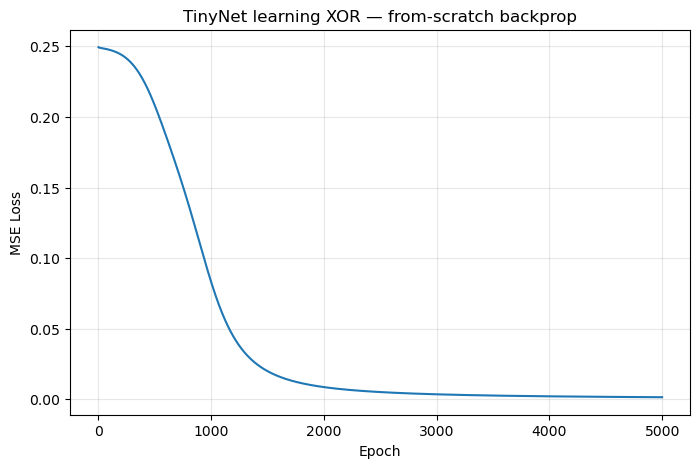

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("TinyNet learning XOR — from-scratch backprop")
plt.grid(True, alpha=0.3)
plt.show()